# RETO SEMANA 3 

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

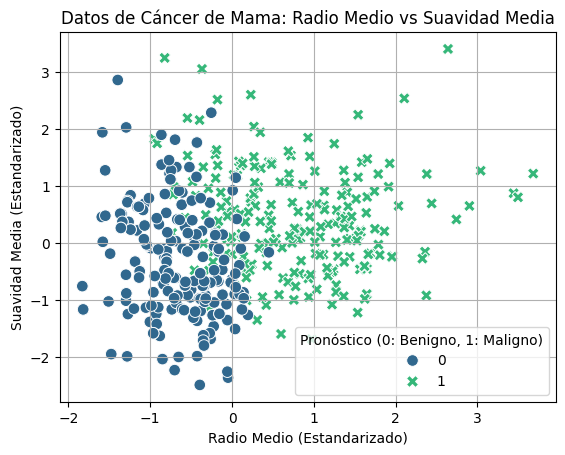

In [16]:
# Leemos los datos 
ruta_archivo = 'BreastCancer.csv'
datos = pd.read_csv(ruta_archivo)

#Hacemos el grafico de dispersion, en este caso utilizamos diferentes colores y formas para una mejor visualización 
grafico_dispersion = sns.scatterplot(
    data=datos,
    x='radius_mean',
    y='smoothness_mean',
    hue='pronostic',
    palette='viridis',
    style='pronostic',
    s=70
)

plt.title('Datos de Cáncer de Mama: Radio Medio vs Suavidad Media')
plt.xlabel('Radio Medio (Estandarizado)')
plt.ylabel('Suavidad Media (Estandarizado)')
plt.legend(title='Pronóstico (0: Benigno, 1: Maligno)')
plt.grid(True)

plt.show()


In [17]:
# Escribimos la funcion para graficar la frontera de decision de los pesos dados en el taller
def graficar_frontera_decision(pesos, grafico_dispersion, datos):
    x_min, x_max = plt.xlim()
    valores_x1 = np.linspace(x_min, x_max, 100)
    valores_x2 = (-pesos[0] * valores_x1 - pesos[2]) / pesos[1]
    plt.plot(
        valores_x1,
        valores_x2,
        'r-',
        linewidth=2,
        label=f'Frontera de decisión: {pesos[0]:.4f}x₁ + {pesos[1]:.4f}x₂ + {pesos[2]:.4f} = 0'
    )
    plt.legend(title='Pronóstico (0: Benigno, 1: Maligno)')
    plt.tight_layout()
    return plt


In [18]:
# Escribimos la funcion para calcular f segun los pesos que se esten usand
def calcular_fw(pesos, caracteristicas, etiquetas):
    pesos = np.array(pesos)
    if caracteristicas.shape[1] == 2:
        caracteristicas_con_bias = np.column_stack((caracteristicas, np.ones(caracteristicas.shape[0])))
    else:
        caracteristicas_con_bias = caracteristicas
    z = np.dot(caracteristicas_con_bias, pesos)
    sigmoide_z = 1 / (1 + np.exp(-z))
    epsilon = 1e-15
    perdida = -np.mean(
        etiquetas * np.log(sigmoide_z + epsilon) +
        (1 - etiquetas) * np.log(1 - sigmoide_z + epsilon)
    )
    return perdida


In [19]:
# Escribimos la funcion para evaluar los candidatos y los graficamos todos en una misma grafica para una mejor visualización 
def evaluar_candidatos(datos, pesos_candidatos):
    X = datos[['radius_mean', 'smoothness_mean']].values
    t = datos['pronostic'].values

    plt.figure(figsize=(12, 10))
    grafico_dispersion = sns.scatterplot(
        data=datos,
        x='radius_mean',
        y='smoothness_mean',
        hue='pronostic',
        palette='viridis',
        style='pronostic',
        s=70
    )

    plt.title('Datos de Cáncer de Mama: Radio Medio vs Suavidad Media con Fronteras de Decisión')
    plt.xlabel('Radio Medio')
    plt.ylabel('Suavidad Media')
    plt.grid(True)

    resultados = []
    colores = ['r', 'g', 'b']

    for i, w in enumerate(pesos_candidatos):
        fw_valor = calcular_fw(w, X, t)
        resultados.append((w, fw_valor))

        x_min, x_max = plt.xlim()
        valores_x1 = np.linspace(x_min, x_max, 100)
        valores_x2 = (-w[0] * valores_x1 - w[2]) / w[1]

        plt.plot(
            valores_x1,
            valores_x2,
            color=colores[i],
            linestyle='-',
            linewidth=2,
            label=f'p{i+1}: f(w)={fw_valor:.4f}'
        )

    plt.legend(title='Leyenda')
    plt.tight_layout()
    plt.show()

    print("Evaluación de vectores de pesos candidatos:")
    for i, (w, fw) in enumerate(resultados):
        print(f"Candidato {i+1}: w = {w}, f(w) = {fw:.6f}")

    mejor_idx = min(range(len(resultados)), key=lambda i: resultados[i][1])
    print(f"\nEl mejor candidato es el #{mejor_idx+1} con f(w) = {resultados[mejor_idx][1]:.6f}")

    return resultados


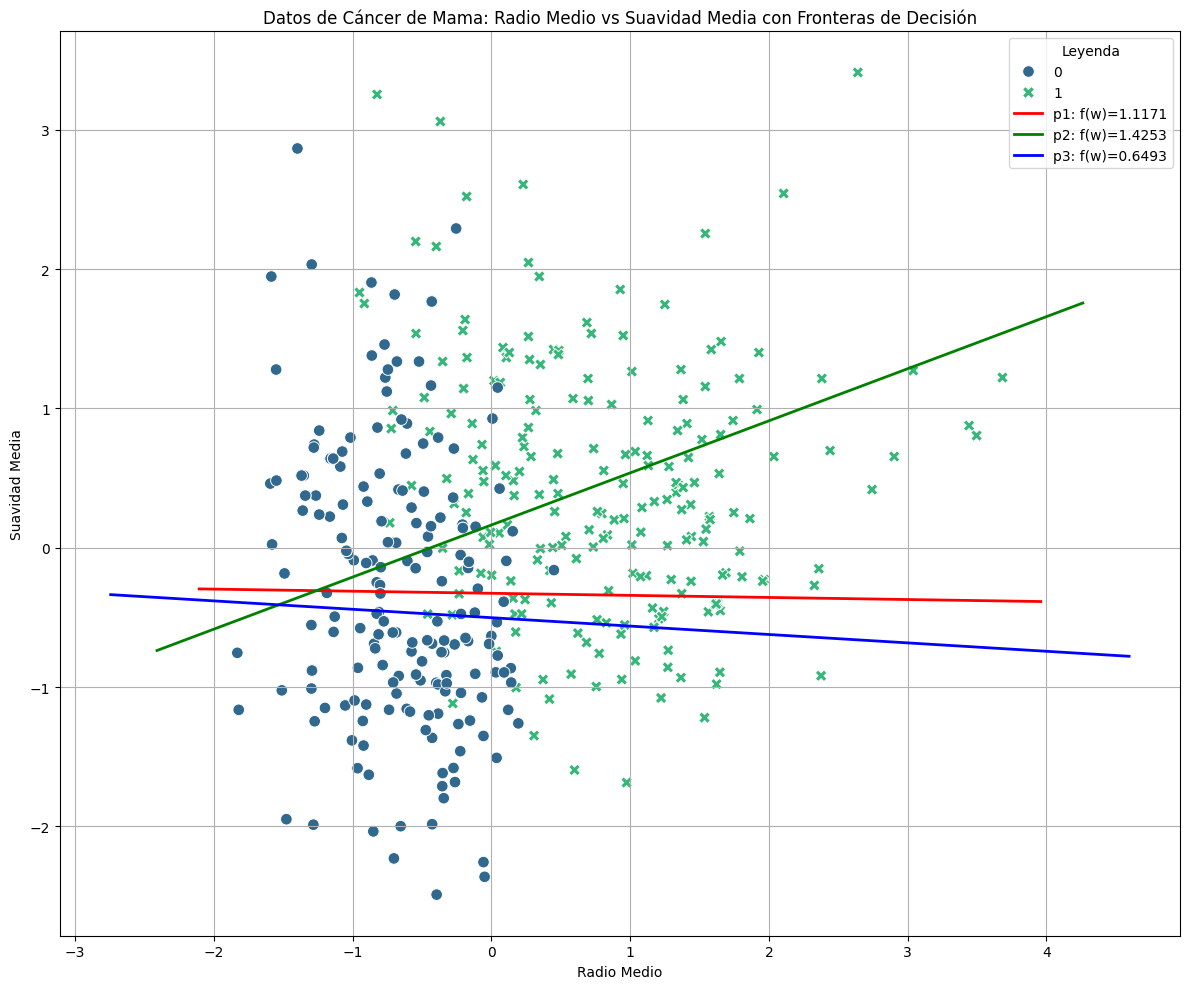

Evaluación de vectores de pesos candidatos:
Candidato 1: w = [0.0603, 4.0364, 1.3192], f(w) = 1.117113
Candidato 2: w = [-1.345, 3.597, -0.588], f(w) = 1.425327
Candidato 3: w = [0.0603, 1.0, 0.502], f(w) = 0.649319

El mejor candidato es el #3 con f(w) = 0.649319


In [20]:
# probamos con los pesos candidatos que fueron dados en el taller 
pesos_candidatos = [
    [0.0603, 4.0364, 1.3192],
    [-1.345, 3.597, -0.588],
    [0.0603, 1.000, 0.502]
]

resultados = evaluar_candidatos(datos, pesos_candidatos)


In [22]:
# Con este funcion definimos el gradiente y el hessiano segun los pesos recibidos
def calcular_gradiente_y_hessiano(pesos, caracteristicas, etiquetas):
    pesos = np.array(pesos)
    if caracteristicas.shape[1] == 2:
        caracteristicas_con_bias = np.column_stack((caracteristicas, np.ones(caracteristicas.shape[0])))
    else:
        caracteristicas_con_bias = caracteristicas
    n_muestras = caracteristicas_con_bias.shape[0]
    z = np.dot(caracteristicas_con_bias, pesos)
    y_pred = 1 / (1 + np.exp(-z))
    error = y_pred - etiquetas
    gradiente = np.dot(caracteristicas_con_bias.T, error) / n_muestras
    S = np.diag(y_pred * (1 - y_pred))
    hessiano = np.dot(caracteristicas_con_bias.T, np.dot(S, caracteristicas_con_bias)) / n_muestras
    return gradiente, hessiano

# Con este funcion realizamos el analisis de los pesos 
def analizar_vectores_de_pesos(datos, pesos_candidatos):
    caracteristicas = datos[['radius_mean', 'smoothness_mean']].values
    etiquetas = datos['pronostic'].values
    print("Análisis de vectores de pesos candidatos:")
    for i, pesos in enumerate(pesos_candidatos):
        gradiente, hessiano = calcular_gradiente_y_hessiano(pesos, caracteristicas, etiquetas)
        valores_propios = np.linalg.eigvals(hessiano)
        magnitud_gradiente = np.linalg.norm(gradiente)
        print(f"\nCandidato {i+1}: pesos = {pesos}")
        print(f"Gradiente: {gradiente}")
        print(f"Magnitud del gradiente: {magnitud_gradiente:.6f}")
        print(f"Matriz Hessiano:\n{hessiano}")
        print(f"Valores propios del Hessiano: {valores_propios}")
        print(f"Hessiano es definido positivo: {all(valores_propios > 0)}")


In [23]:
# Realizamos el analisis de los pesos 
analizar_vectores_de_pesos(data, pesos_candidatos)

Análisis de vectores de pesos candidatos:

Candidato 1: pesos = [0.0603, 4.0364, 1.3192]
Gradiente: [-0.28000648  0.16189668  0.15276762]
Magnitud del gradiente: 0.357704
Matriz Hessiano:
[[ 0.07692541  0.00175094  0.00288322]
 [ 0.00175094  0.02176841 -0.02514309]
 [ 0.00288322 -0.02514309  0.08637066]]
Valores propios del Hessiano: [0.01303093 0.07677542 0.09525813]
Hessiano es definido positivo: True

Candidato 2: pesos = [-1.345, 3.597, -0.588]
Gradiente: [-0.44078326  0.14172474 -0.03558868]
Magnitud del gradiente: 0.464373
Matriz Hessiano:
[[0.09623497 0.03106947 0.00496521]
 [0.03106947 0.02892317 0.01026364]
 [0.00496521 0.01026364 0.09432526]]
Valores propios del Hessiano: [0.01600031 0.11239276 0.09109032]
Hessiano es definido positivo: True

Candidato 3: pesos = [0.0603, 1.0, 0.502]
Gradiente: [-0.31214392  0.01112377  0.14757028]
Magnitud del gradiente: 0.345448
Matriz Hessiano:
[[ 0.18762982  0.02974826 -0.00548253]
 [ 0.02974826  0.14063429 -0.03507823]
 [-0.00548253 -0.0

El Candidato 3 muestra la magnitud de gradiente más pequeña, acercándose más al punto óptimo, y sus valores propios del hessiano ([0.1155, 0.1868, 0.2256]) son notablemente mayores que en los otros dos, lo que implica una curvatura más marcada y, por ende, una convergencia más estable.